In [605]:
import pandas as pd
import numpy as np

df = pd.read_csv('D:\DS111\Bai_TH\dataset_v2.csv')

In [606]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21000 non-null  int64  
 1   date           21000 non-null  object 
 2   price          20998 non-null  object 
 3   bedrooms       20985 non-null  float64
 4   bathrooms      20988 non-null  object 
 5   sqft_living    21000 non-null  int64  
 6   sqft_lot       20987 non-null  object 
 7   floors         21000 non-null  object 
 8   waterfront     21000 non-null  object 
 9   view           20996 non-null  object 
 10  condition      21000 non-null  object 
 11  grade          21000 non-null  int64  
 12  grade_v2       21000 non-null  object 
 13  sqft_above     21000 non-null  int64  
 14  sqft_basement  20980 non-null  object 
 15  yr_built       21000 non-null  int64  
 16  yr_renovated   21000 non-null  object 
 17  zipcode        21000 non-null  int64  
 18  lat   

#### 1. Xử lý giá trị bị khuyết:

    Biến "bedrooms", "bathrooms", "view", "sqft_basement", "sqft_lot" tự chọn phương pháp điền khuyết, giải thích cách chọn phương pháp.
    
    Nếu còn lại các biến khác bị khuyết thì loại bỏ mẫu dữ liệu.

In [607]:
df.isnull().sum()

id                0
date              0
price             2
bedrooms         15
bathrooms        12
sqft_living       0
sqft_lot         13
floors            0
waterfront        0
view              4
condition         0
grade             0
grade_v2          0
sqft_above        0
sqft_basement    20
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [608]:
list_missing_values = ['?', '.', '-', 'nan', 'NAN', 'NA', 'NaT', 'None']
for col in df.columns:
    for miss in list_missing_values:
        miss_count = df[col][df[col] == miss].count()
        if miss_count > 0:
            print(f'column {col} has {miss_count} missing values represented by {miss}')   

column price has 14 missing values represented by ?
column bathrooms has 11 missing values represented by .
column sqft_lot has 1 missing values represented by NAN
column floors has 17 missing values represented by -
column sqft_basement has 1 missing values represented by NAN
column yr_renovated has 10 missing values represented by NAN


In [609]:
df = df.replace(["?", ".", "-",'NAN'], np.nan)

In [610]:
df.isnull().sum()

id                0
date              0
price            16
bedrooms         15
bathrooms        23
sqft_living       0
sqft_lot         14
floors           17
waterfront        0
view              4
condition         0
grade             0
grade_v2          0
sqft_above        0
sqft_basement    21
yr_built          0
yr_renovated     10
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

bedrooms số phòng ngủ có giá trị trong dataset là biến rời rạc

Dùng mode để lấy giá trị phổ biến nhất cấu trúc số phòng ngủ của 1 ngôi nhà điển hình

In [611]:
# bedrooms
df['bedrooms'].fillna(df['bedrooms'].mode()[0], inplace=True) 

C:\Users\Thy\AppData\Local\Temp\ipykernel_4416\4126857860.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].fillna(df['bedrooms'].mode()[0], inplace=True)


bathrooms là biến số liên tục phân phối thường lệch phải (ít nhà có rất nhiều phòng tắm)

Dùng median để lấy giá trị phổ biến số lượng phòng tắm của 1 ngôi nhà điển hình

In [612]:
# bathrooms 
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)

C:\Users\Thy\AppData\Local\Temp\ipykernel_4416\782488789.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)


view là biến phân loại/ordinal

Dùng mode để lấy giá trị phổ biến nhất view nhà của 1 ngôi nhà điển hình

In [613]:
# view 
df['view'].fillna(df['view'].mode()[0], inplace=True)

C:\Users\Thy\AppData\Local\Temp\ipykernel_4416\4120241548.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['view'].fillna(df['view'].mode()[0], inplace=True)


Với giá trị khuyết sẽ ghi nhận thành 0 -> không có tầng hầm 
Vì quan sát các giá trị của sqft_basement là các biến rời rạc và nhiều giá trị lớn chệch lệch giữa các mẫu và có nhiều giá trị 0 (sqft_basement = 0 có ý nghĩa: nhà không có tầng hầm) nên lấy giá trị 0 vì đa số ngôi nhà điển hình không có tầng hầm, và giá trị diện tích tầng hầm của các nhà có tầng hầm có giá trị chênh lệch lớn nên không nên lấy mean hay median

In [614]:
# sqft_basement 
df['sqft_basement'] = pd.to_numeric(df['sqft_basement'], errors='coerce')
df['sqft_basement'].fillna(0, inplace=True)

C:\Users\Thy\AppData\Local\Temp\ipykernel_4416\425733466.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sqft_basement'].fillna(0, inplace=True)


Quan sát sqft_lot do phân phối lệch và có outlier

Median phản ánh diện tích lô đất điển hình hơn

In [615]:
# sqft_lot 
df['sqft_lot'] = pd.to_numeric(df['sqft_lot'], errors='coerce')
df['sqft_lot'].fillna(df['sqft_lot'].median(), inplace=True)

C:\Users\Thy\AppData\Local\Temp\ipykernel_4416\3475085459.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sqft_lot'].fillna(df['sqft_lot'].median(), inplace=True)


Quan sát thấy đa số nhà đều có 1 lầu nên lấy giá trị 1 cho số lầu cho các giá trị khuyết

In [616]:
# floors
df['floors'] = pd.to_numeric(df['floors'], errors='coerce')
df['floors'].fillna(1, inplace=True)

C:\Users\Thy\AppData\Local\Temp\ipykernel_4416\96123542.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floors'].fillna(1, inplace=True)


In [617]:
# Các cột có giá trị missing value khác 
df.dropna(axis='index', subset=  ["price", 'floors', 'yr_renovated'], inplace=True)

In [618]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
grade_v2         0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

#### 2. Có thể dùng loại trực quan gì cho biến "floors"? Bình luận kết quả trực quan (nếu có)?

floors là biến số rời rạc / ordinal, quan sát thấy giá trị thường gặp: 1, 1.5, 2, 2.5, 3, …-> Không phải biến liên tục hoàn toàn.

=> Biểu đồ cột (Bar chart / Count plot) là phù hợp nhất

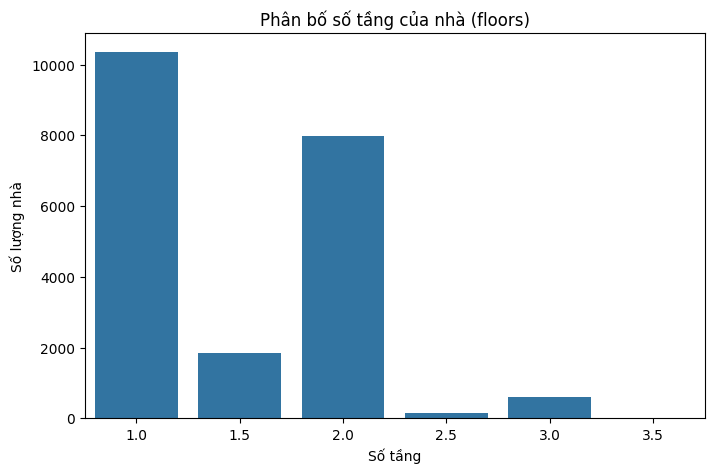

In [619]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(8,5))
sns.countplot(x='floors', data=df, order=sorted(df['floors'].dropna().unique()))
plt.title('Phân bố số tầng của nhà (floors)')
plt.xlabel('Số tầng')
plt.ylabel('Số lượng nhà')
plt.show()

Quan sát biểu đồ cột của biến floors cho thấy phần lớn các căn nhà trong tập dữ liệu có 1 hoặc 2 tầng, trong đó nhà 1 tầng chiếm tỷ lệ cao nhất. Các giá trị lớn hơn như 3 tầng hoặc hơn xuất hiện với tần suất rất thấp. Điều này phản ánh đặc điểm phổ biến của nhà ở trong khu vực nghiên cứu, đồng thời cho thấy phân phối của biến floors là lệch phải.

#### 3. Có thể dùng loại trực quan gì cho biến "waterfront"? Bình luận kết quả trực quan (nếu có)?

waterfront là biến phân loại (categorical – nominal), các giá trị không có thứ tự lớn–nhỏ rõ ràng

=> Biểu đồ cột (Bar chart / Count plot) là phù hợp nhất

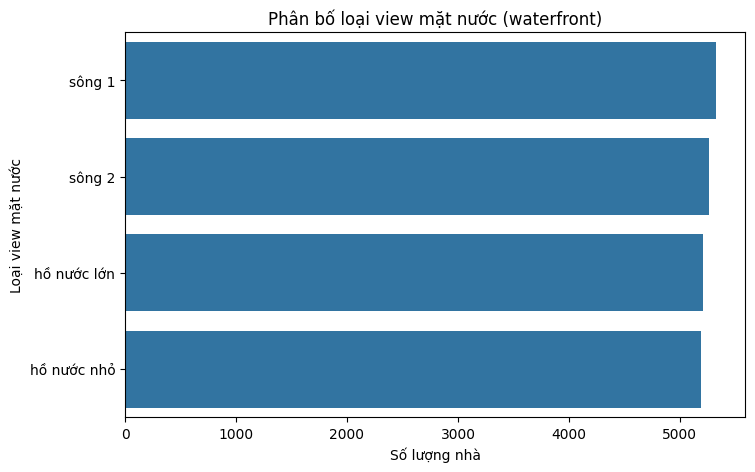

In [620]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    y='waterfront',
    data=df,
    order=df['waterfront'].value_counts().index
)
plt.title('Phân bố loại view mặt nước (waterfront)')
plt.xlabel('Số lượng nhà')
plt.ylabel('Loại view mặt nước')
plt.show()


Biểu đồ cột cho thấy số lượng nhà thuộc các loại view mặt nước như “sông 1”, “sông 2”, “hồ nước nhỏ” và “hồ nước lớn” là tương đối đồng đều. Không có loại view nào chiếm ưu thế rõ rệt so với các loại còn lại. Điều này cho thấy trong tập dữ liệu hiện tại, biến waterfront có phân phối khá cân bằng giữa các nhóm.

#### 4. Sử dụng trực quan regplot để đánh giá, kiểm tra thử ảnh hưởng của các biến loại diện tích (sqft_...) so với giá. Phác họa trên cùng một hình. Sau đó, bình luận các kết quả?

In [621]:
cols = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
for col in cols + ['price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

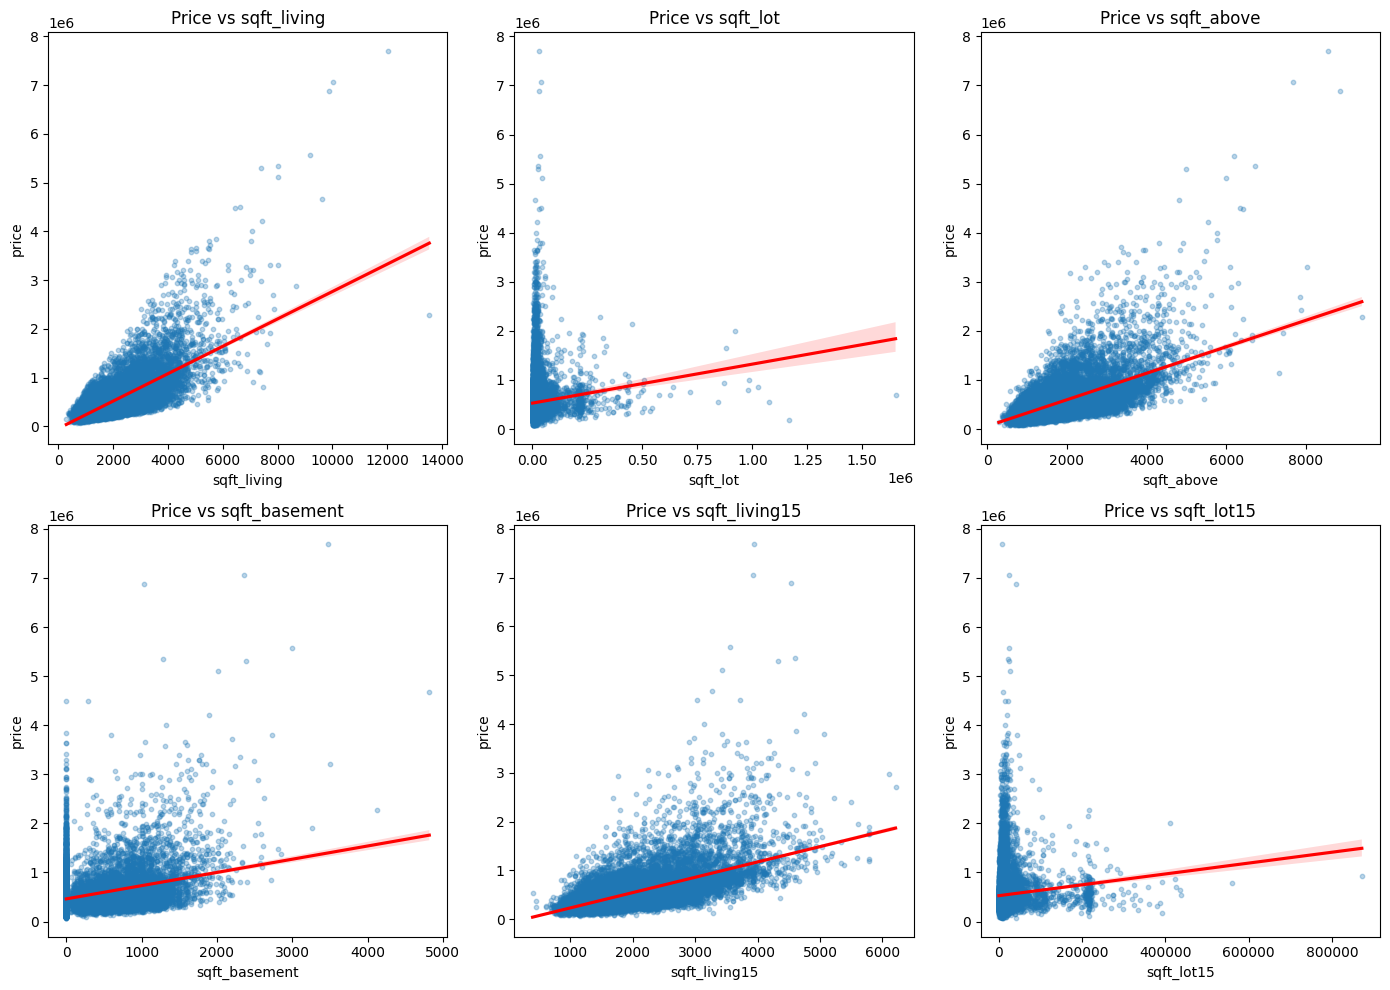

In [622]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.regplot(
        x=col,
        y='price',
        data=df,
        scatter_kws={'alpha': 0.3, 's': 10},
        line_kws={'color': 'red'}
    )
    plt.title(f'Price vs {col}')

plt.tight_layout()
plt.show()

Qua biểu đồ regplot, ta thấy sqft_living, sqft_living15, sqft_above lần lượt là các biến diện tích nhà, diện tích phòng khách vào năm 2015, diện tích nhà ngoài tầng hầm thể hiện mối quan hệ tuyến tính dương khá rõ ràng với giá nhà. Khi diện tích sinh hoạt tăng, giá nhà có xu hướng tăng theo, cho thấy đây là những biến có ảnh hưởng mạnh đến giá.

Ngược lại, các biến liên quan đến diện tích đất như sqft_lot và sqft_lot15 cho thấy mối quan hệ với giá yếu hơn và phân tán hơn, đặc biệt ở các giá trị diện tích nhỏ. Điều này cho thấy giá nhà không quá phụ thuộc vào diện tích đất mà chịu ảnh hưởng hơn từ diện tích ngôi nhà, và các đặc điểm trong ngôi nhà 

Cũng giống như sqft_lot và sqft_lot15, biến sqft_basement có xu hướng tác động dương đến giá, tuy nhiên mức độ ảnh hưởng không mạnh và dữ liệu phân bố không đồng đều do nhiều căn nhà không có tầng hầm.

#### 5. Xây dựng mô hình thích hợp dự đoán giá nhà từ các biến sau "floors", "view", "waterfront", "bedrooms", "grade", "bathrooms", "sqft_living15", "sqft_above", "sqft_living", "sqft_basement". (Yêu cầu: phải áp dụng kỹ thuật Pipeline và thang đo thích hợp nhất).

In [623]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [624]:
features = [
    "floors", "view", "waterfront", "bedrooms", "grade",
    "bathrooms", "sqft_living15", "sqft_above",
    "sqft_living", "sqft_basement"
]

X = df[features]
y = df["price"]

categorical_features = ["view", "waterfront"]  
numerical_features = [
    "floors", "bedrooms", "grade", "bathrooms",
    "sqft_living15", "sqft_above",
    "sqft_living", "sqft_basement"
]

In [625]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [626]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [627]:
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("reg", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['floors', 'bedrooms',
                                                   'grade', 'bathrooms',
                                                   'sqft_living15',
                                                   'sqft_above', 'sqft_living',
                                                   'sqft_basement']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['view', 'waterfront'])])),
                ('reg', LinearRegression())])

In [628]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Dự đoán
y_pred = model.predict(X_test)

# R2
print("R2 (qua r2_score):", r2_score(y_test, y_pred))
print("R2 (qua model.score):", model.score(X_test, y_test))

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


rmse = np.sqrt(mse)
print("RMSE:", rmse)

R2 (qua r2_score): 0.5924318338869999
R2 (qua model.score): 0.5924318338869999
MSE: 54794781944.09681
RMSE: 234082.8527340198


#### Câu 6: Nhà thuộc cấp loại gì, và có view như thế nào thì có ảnh hưởng đến trung bình giá nhà? Phân tích nhóm 
- Đánh giá mô hình -> tìm  ra công thức,
- Dùng hết dữ liệu để tìm ra mô  hình cơ sở (Thăm dò dữ liệu để biết có mấy loại mô hình có  khả  năng) -> đánh giá ngoài mẫu (out-of-sample  evaluation)(random  bằng train_test_split), đánh giá chéo (cross-validation evaluation) 

In [629]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20974 entries, 0 to 20999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             20974 non-null  int64  
 1   date           20974 non-null  object 
 2   price          20974 non-null  int64  
 3   bedrooms       20974 non-null  float64
 4   bathrooms      20974 non-null  float64
 5   sqft_living    20974 non-null  int64  
 6   sqft_lot       20974 non-null  float64
 7   floors         20974 non-null  float64
 8   waterfront     20974 non-null  object 
 9   view           20974 non-null  object 
 10  condition      20974 non-null  object 
 11  grade          20974 non-null  int64  
 12  grade_v2       20974 non-null  object 
 13  sqft_above     20974 non-null  int64  
 14  sqft_basement  20974 non-null  float64
 15  yr_built       20974 non-null  int64  
 16  yr_renovated   20974 non-null  object 
 17  zipcode        20974 non-null  int64  
 18  lat        

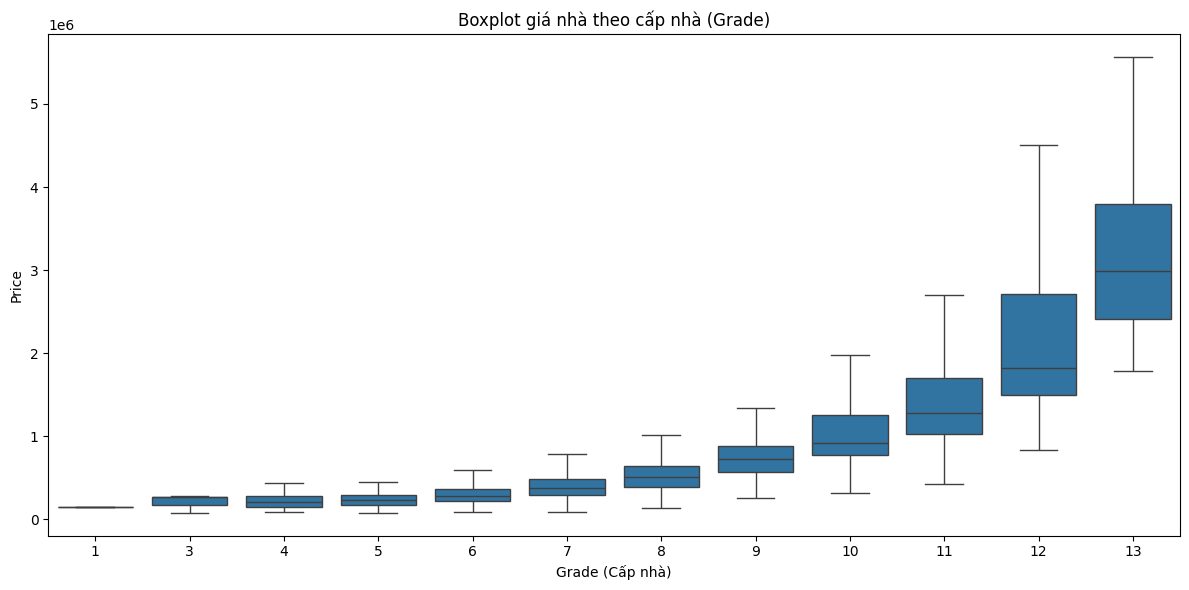

In [630]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(
    x="grade",
    y="price",
    data=df,
    showfliers=False   # ẩn outlier để nhìn rõ xu hướng
)

plt.title("Boxplot giá nhà theo cấp nhà (Grade)")
plt.xlabel("Grade (Cấp nhà)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [631]:
df["view"].value_counts()

view
Không                18912
Siêu thị tiện lợi      937
Trường học             492
Nhà đối diện           322
Công viên              311
Name: count, dtype: int64

In [632]:
pivot = (
    df
    .groupby(["grade", "view"])["price"]
    .mean()
    .unstack()
)

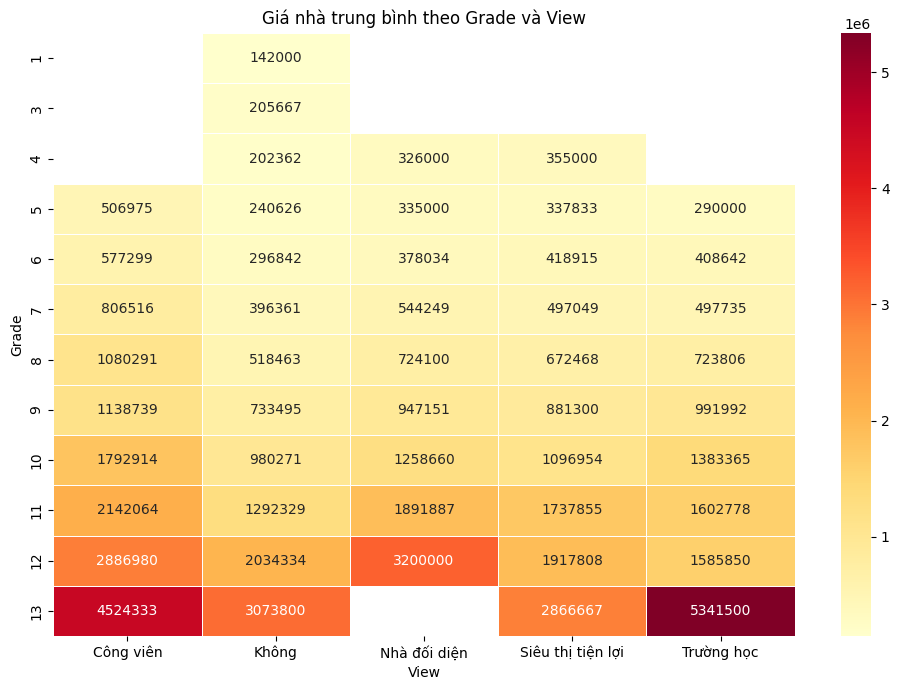

In [633]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Giá nhà trung bình theo Grade và View")
plt.xlabel("View")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()


1.  Giá nhà dưới 1 triệu chiếm phổ biến với cấp loại từ 1 đến 9 với mọi View và cả không có View

2.  Tuy nhiên với View Công Viên thì từ cấp loại 8 giá nhà đã vượt qua 1 triệu
    Từ cấp 9 các loại nhà có View đã có giá trị >800.000 xấp xỉ 1 triệu 
    
3.  Từ các cấp bậc cao hơn từ 10 -> 12 giá nhà giao động từ > 1 triệu đến < 3 triệu. 
    Trừ nhà có View là Nhà đối diện thì giá nhà trung bình 3.200.000 => Nhà có view nhà đối diện thường nằm ở các đường phố có quy hoạch thuộc trung tâm nên có thể có giá nhà cao hơn so với những nhà cùng bậc có view khác.
    Từ cấp 10-12 thì nhà không có View có giá trung bình thấp hơn nhiều so với nhà có view, khảng chênh lệch lên đến xấp xỉ 1 triệu.
    
4.  Cấp loại cao nhất 13 nhà có View Siêu thị tiện lợi và không có view có giá trung bình 2 triệu 8 trăm đến 3 triệu=> Cao hơn so với cấp bậc 12 với cùng loại View đến 1 triệu
    Nhà có View Công viên và Trường học có giá trung bình 4 triệu 500 đến hơn 5 triệu -> tăng vượt bật giá so với cấp 12 với nhà cùng loại view tăng đến 2 triệu cho view Công viên và 4 triệu cho Trường học

Kết luận

    - Giá nhà dưới 1 triệu USD chủ yếu tập trung ở các cấp loại từ 1 đến 9, gần như không chịu ảnh hưởng đáng kể từ yếu tố view. 
    - Khi cấp loại nhà tăng lên từ 8–9 trở đi, các căn nhà có view bắt đầu có giá cao hơn rõ rệt so với nhà không có view. 
    - Ở các cấp loại cao (10–12), nhà có view có giá trung bình cao hơn đáng kể, trong khi nhà không có view có mức giá thấp hơn rõ rệt. 
    - Đối với cấp loại cao nhất (grade 13), các căn nhà có view tốt như Công viên và Trường học đạt mức giá trung bình cao nhất, cho thấy view có vai trò quan trọng trong việc gia tăng giá trị nhà ở ở phân khúc cao cấp.

In [634]:
X = df[["grade", "view"]]
y = df["price"]

In [635]:
numeric_features = ["grade"]
categorical_features = ["view"]

In [636]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=1, include_bias=False))
    ]
)

categorical_transformer = OneHotEncoder(drop="first")

In [637]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [638]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]
)

In [639]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập validation:", X_val.shape)
print("Kích thước tập test:", X_test.shape)

Kích thước tập train: (12584, 2)
Kích thước tập validation: (4195, 2)
Kích thước tập test: (4195, 2)


In [640]:
results = []

for degree in range(1, 7):  
    
    pipeline.set_params(
        preprocessing__num__poly__degree=degree
    )
    
    # Fit trên train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    
    # Error
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    
    results.append({
        "degree": degree,
        "Train_MSE": train_mse,
        "Validation_MSE": val_mse
    })

results_df = pd.DataFrame(results)
print(results_df)

best_degree = results_df.loc[results_df["Validation_MSE"].idxmin(), "degree"]
print("Bậc đa thức tốt nhất (dựa trên validation):", best_degree)

   degree     Train_MSE  Validation_MSE
0       1  6.460034e+10    7.400889e+10
1       2  5.768945e+10    6.584832e+10
2       3  5.683814e+10    6.495523e+10
3       4  5.657751e+10    6.503699e+10
4       5  5.643010e+10    6.529054e+10
5       6  5.628398e+10    6.550719e+10
Bậc đa thức tốt nhất (dựa trên validation): 3


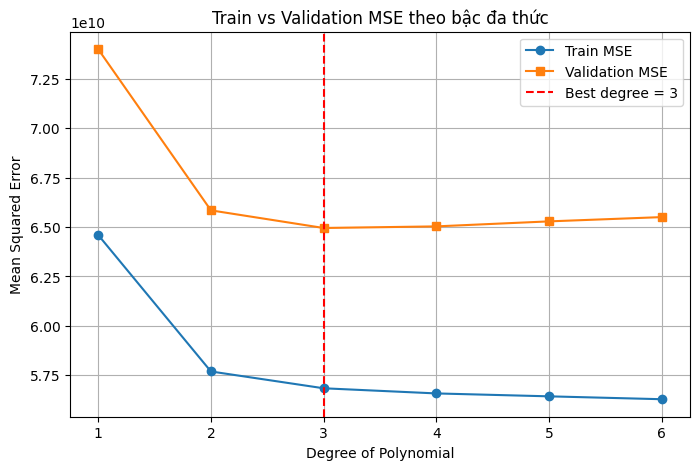

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df['degree'], results_df['Train_MSE'], marker='o', label='Train MSE')
plt.plot(results_df['degree'], results_df['Validation_MSE'], marker='s', label='Validation MSE')

best_degree = results_df.loc[results_df["Validation_MSE"].idxmin(), "degree"]
plt.axvline(best_degree, color='red', linestyle='--', label=f'Best degree = {best_degree}')

plt.xlabel("Degree of Polynomial")
plt.ylabel("Mean Squared Error")
plt.title("Train vs Validation MSE theo bậc đa thức")
plt.xticks(results_df['degree'])
plt.legend()
plt.grid(True)
plt.show()

In [642]:
best_degree = 3

pipeline.set_params(preprocessing__num__poly__degree=best_degree)

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])
pipeline.fit(X_train_val, y_train_val)

y_test_pred = pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE (degree {best_degree}):", test_mse)
print(f"Test R2 (degree {best_degree}):", test_r2)

Test MSE (degree 3): 57101763474.24252
Test R2 (degree 3): 0.57527231252131
